In [1]:
# !pip -q install torch torchvision scikit-learn matplotlib tqdm ipython-autotime

In [2]:
!pip install ipython-autotime


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# %load_ext autotime

In [1]:
import random, os, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn                      # layers & losses as objects (they hold weights)
import torch.nn.functional as F            # the same maths as stateless functions
import torch.optim as optim                # SGD, Adam, ...
from torch.utils.data import DataLoader    # turns a Dataset into shuffled batches
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

print("torch      :", torch.__version__)
import torchvision; print("torchvision:", torchvision.__version__)

torch      : 2.10.0
torchvision: 0.25.0


In [2]:
def set_seed(seed=9999):
    random.seed(seed)                          # Python's own RNG
    np.random.seed(seed)                       # NumPy's RNG
    torch.manual_seed(seed)                    # PyTorch CPU + MPS
    torch.cuda.manual_seed_all(seed)           # every CUDA GPU (no-op if there is none)
    torch.backends.cudnn.deterministic = True  # pick reproducible cuDNN kernels...
    torch.backends.cudnn.benchmark = False     # ...instead of the fastest-found ones

set_seed(42)
print("seeded")

seeded


In [3]:
if torch.backends.mps.is_available():          # Apple Silicon GPU
    device = torch.device("mps")
elif torch.cuda.is_available():                # NVIDIA GPU
    device = torch.device("cuda")
else:
    device = torch.device("cpu")               # always works, just slower

print("Device:", device)

Device: mps


In [4]:
DATA_ROOT = Path("data")           # torchvision creates/uses ./data/MNIST and ./data/cifar-100-python
DATA_ROOT.mkdir(exist_ok=True)
print("data root:", DATA_ROOT.resolve())

data root: /Users/shivam13juna/Documents/scaler/iitr_classes/july_2026/Intro_To_PyTorch/data


1. 1D data -> Vector/np array
2. 2D data -> Matrix/ np array
3. >= 3D data -> Tensor/np.array

```text
P0 setup → ●P1 TENSOR VS NUMPY → P2 autograd → P3 nn.Module → P4 dataloader →
P5 mnist+mlp → P6 cifar+mlp → P7 cifar+cnn → P8 save+predict
```

# Part 1 — A tensor is a NumPy array with two extra powers

Good news: you already know most of this.

A **tensor** is an n-dimensional array of numbers — exactly the same idea as `np.ndarray`.
Same shapes, same indexing, same `+ - * /`, same `.sum()` and `.mean()`. If you can write
NumPy, you can read tensor code today without learning a new mental model.

So why does PyTorch have its own array type instead of just using NumPy? Two reasons, and
they are the entire content of this Part:

| | NumPy | PyTorch tensor |
|---|---|---|
| n-dim array of numbers | ✅ | ✅ |
| runs on the **GPU** | ❌ CPU only | ✅ `.to(device)` |
| **remembers what was done to it**, so it can compute gradients | ❌ | ✅ `requires_grad=True` |

That second row is the one that matters. It is why this notebook exists, and Part 2 is
entirely about it.

**We are not doing a tour of the tensor API.** You will pick that up by using it. This Part
is five short cells: make one, prove it behaves like NumPy, then meet the two differences.


In DL models, all parameters are initialized to random numbers. And they're updated with their gradients, computed in backprop.  

In [8]:
a = torch.tensor([1.0, 2.0, 3.0])       # from a Python list
b = torch.zeros(2, 3)                   # shape (2, 3), all zeros
c = torch.randn(2, 3)                   # shape (2, 3), random normal — the one you'll use most

print("a       :", a)
print("a.shape :", a.shape, "  <- like np.shape")
print("a.dtype :", a.dtype, " <- float32, NOT float64 like NumPy's default")
print()
print("c =\n", c)

a       : tensor([1., 2., 3.])
a.shape : torch.Size([3])   <- like np.shape
a.dtype : torch.float32  <- float32, NOT float64 like NumPy's default

c =
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])


In [9]:
c.size(1)

3

In [10]:
a.grad

In [11]:
a.requires_grad

False

In [12]:
# ano = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

In [13]:
a[0], a[1], a[[0, 2]]

(tensor(1.), tensor(2.), tensor([1., 3.]))

In [14]:
arr = np.array([1.0, 2.0, 3.0])
ten = torch.from_numpy(arr)                    # numpy -> torch

print("numpy :", arr * 2 + 1, "  mean =", arr.mean())
print("torch :", ten * 2 + 1, "  mean =", ten.mean().item())
print("       ^ same numbers.")

print("\nand back again:", ten.numpy(), type(ten.numpy()))

print("\ndtype came along for the ride:", ten.dtype, "  <- NumPy's default, not PyTorch's")
print("models want float32, so you convert:", ten.float().dtype)

numpy : [3. 5. 7.]   mean = 2.0
torch : tensor([3., 5., 7.], dtype=torch.float64)   mean = 2.0
       ^ same numbers.

and back again: [1. 2. 3.] <class 'numpy.ndarray'>

dtype came along for the ride: torch.float64   <- NumPy's default, not PyTorch's
models want float32, so you convert: torch.float32


In [15]:
ten.mean().item()

2.0

In [16]:
device

device(type='mps')

## Power 1

In [17]:
cpu_tensor = torch.randn(3)
gpu_tensor = cpu_tensor.to(device)               # a NEW tensor, on the accelerator

print("original stays put :", cpu_tensor.device)
print("copy moved to      :", gpu_tensor.device)



try:
  cpu_tensor + gpu_tensor

except Exception as e:
  print(e)

original stays put : cpu
copy moved to      : mps:0
Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu!


## Power 2

In [18]:
w = torch.tensor(5.0, requires_grad=True)     # "I will want a gradient for this"
w.grad

In [19]:
out = (w - 3) ** 2                            # do some maths

In [20]:
print("out       :", out)

out       : tensor(4., grad_fn=<PowBackward0>)


### Example 1

In [21]:
x = torch.tensor(5.0, requires_grad=True)      # we want dy/dx
z = torch.tensor(2.0, requires_grad=True)      # ...and dy/dz

print("x =", x)
print("x.requires_grad :", x.requires_grad)
print("x.grad          :", x.grad, "  <- None: nothing has been computed backwards yet")
print("x.item()        :", x.item(), " <- the raw Python float")

x = tensor(5., requires_grad=True)
x.requires_grad : True
x.grad          : None   <- None: nothing has been computed backwards yet
x.item()        : 5.0  <- the raw Python float


In [22]:
y = (x - 3)**2 + z

print("y        =", y.item(), "   ( (5-3)^2 + 2 = 4 + 2 = 6 )")

y        = 6.0    ( (5-3)^2 + 2 = 4 + 2 = 6 )


$$\frac{\partial y}{\partial x} = 2(x-3) = 2(5-3) = \mathbf{4}
\qquad
\frac{\partial y}{\partial z} = \mathbf{1}$$

In [23]:
y.backward()          # walk the graph backwards, apply the chain rule

In [24]:
print("x.grad =", x.grad.item(), "  (hand-derived: 2*(5-3) = 4)   ✓")
print("z.grad =", z.grad.item(), "  (hand-derived: 1)             ✓")

x.grad = 4.0   (hand-derived: 2*(5-3) = 4)   ✓
z.grad = 1.0   (hand-derived: 1)             ✓


rate of change of y with respect to rate of change of x


z = 1, x = 5, y = 6
z = 1, x = 6, y = 10

In [25]:
x, x.grad

(tensor(5., requires_grad=True), tensor(4.))

In [26]:
# x = x - x.grad

### Example 2

In [27]:
x = torch.tensor(5.0, requires_grad=True)

y1 = (x - 3)**2; y1.backward()
print("after 1st backward :", x.grad.item(), "  <- correct")

after 1st backward : 4.0   <- correct


In [28]:
y2 = (x - 3)**2; y2.backward()
print("after 2nd backward :", x.grad.item(), "  <- ACCUMULATED, not recomputed (4 + 4)")

after 2nd backward : 8.0   <- ACCUMULATED, not recomputed (4 + 4)


In [29]:
y3 = (x - 3)**2; y3.backward()
print("after 3rd backward :", x.grad.item(), "  <- ACCUMULATED, not recomputed (4 + 4)")

after 3rd backward : 12.0   <- ACCUMULATED, not recomputed (4 + 4)


In [30]:
x, x.grad

(tensor(5., requires_grad=True), tensor(12.))

In [31]:
x = torch.tensor(5.0, requires_grad=True)

with torch.no_grad():
    y = (x - 3)**2

try:
  y.backward()
except Exception as e:
  print(e)

element 0 of tensors does not require grad and does not have a grad_fn


# Data Loaders

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),                              # PIL (H,W,C) uint8 -> tensor (C,H,W) float in [0,1]
    transforms.Normalize((0.1307,), (0.3081,)),         # MNIST's own mean/std (1 channel -> 1 value)
])

print(transform)

Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)


In [9]:
train_ds = datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

print("train:", len(train_ds), "| test:", len(test_ds))
print("classes:", train_ds.classes)

img, label = train_ds[0]                                # a Dataset is INDEXABLE — this is __getitem__
print("\none sample -> image", tuple(img.shape), img.dtype, "| label", label, type(label).__name__)
print("pixel range after Normalize: %.2f to %.2f" % (img.min(), img.max()))

train: 60000 | test: 10000
classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

one sample -> image (1, 28, 28) torch.float32 | label 5 int
pixel range after Normalize: -0.42 to 2.82


In [10]:
BATCH_SIZE = 128
use_pin = torch.cuda.is_available()                     # pinned memory only benefits CUDA

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=use_pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=use_pin)

print(f"{len(train_loader)} training batches of {BATCH_SIZE}  (60000 / 128 = 468.75 -> last one is short)")
print(f"{len(test_loader)} test batches")

469 training batches of 128  (60000 / 128 = 468.75 -> last one is short)
79 test batches


In [35]:
images, labels = next(iter(train_loader))               # iter() then next() = fetch one batch

print("images:", tuple(images.shape), images.dtype, "  <- (N, C, H, W)")
print("labels:", tuple(labels.shape), labels.dtype, "  <- int64, as CrossEntropyLoss wants")
print("first 12 labels:", labels[:12].tolist())
print("pixel range: %.2f to %.2f  (normalised, so negatives are expected)" % (images.min(), images.max()))

images: (128, 1, 28, 28) torch.float32   <- (N, C, H, W)
labels: (128,) torch.int64   <- int64, as CrossEntropyLoss wants
first 12 labels: [6, 7, 3, 2, 1, 8, 4, 7, 0, 7, 5, 6]
pixel range: -0.42 to 2.82  (normalised, so negatives are expected)


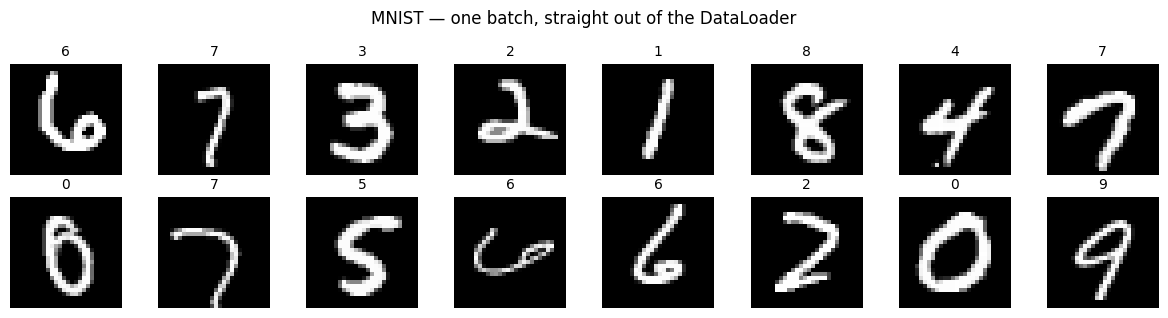

In [36]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, lab in zip(axes.flat, images, labels):
    ax.imshow(img.squeeze(0), cmap="gray")             # squeeze: (1,28,28) -> (28,28) for imshow
    ax.set_title(int(lab), fontsize=10); ax.axis("off")
plt.suptitle("MNIST — one batch, straight out of the DataLoader"); plt.tight_layout(); plt.show()

In [37]:
for epoch in range(3):
    print(f"epoch {epoch} | train (shuffled): {next(iter(train_loader))[1][:8].tolist()}"
          f" | test (fixed): {next(iter(test_loader))[1][:8].tolist()}")

epoch 0 | train (shuffled): [4, 8, 8, 1, 2, 6, 1, 9] | test (fixed): [7, 2, 1, 0, 4, 1, 4, 9]
epoch 1 | train (shuffled): [7, 3, 5, 7, 3, 7, 1, 9] | test (fixed): [7, 2, 1, 0, 4, 1, 4, 9]
epoch 2 | train (shuffled): [7, 2, 5, 1, 8, 1, 9, 0] | test (fixed): [7, 2, 1, 0, 4, 1, 4, 9]


In [38]:
a = np.random.randn(4, 4)
a

array([[ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986],
       [-0.23415337, -0.23413696,  1.57921282,  0.76743473],
       [-0.46947439,  0.54256004, -0.46341769, -0.46572975],
       [ 0.24196227, -1.91328024, -1.72491783, -0.56228753]])

In [39]:
a.reshape(2, -1).shape

(2, 8)

In [44]:
#a.reshape(32, -1).shape

In [53]:
class MLP(nn.Module):
    def __init__(self, in_features=28*28, n_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 128)          # 784 -> 128 # [784, 128]
        self.fc2 = nn.Linear(128, 64)                   # 128 -> 64
        self.fc3 = nn.Linear(64, n_classes)             # 64  -> 10 logits

    def forward(self, x):
        x = x.view(x.size(0), -1)                       # (N,1,28,28) -> (N,784); keep the batch dim
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                                 # no activation here — raw logits
        return x

    #def forward(self, x):
    ## Input image batch
    ## Shape: (N, 1, 28, 28)
    ## N = batch size
    ## Example: (32, 1, 28, 28)

    #x = x.view(x.size(0), -1)

    ## Flatten each image:
    ## (N, 1, 28, 28) -> (N, 784)
    ## Example: (32, 1, 28, 28) -> (32, 784)

    #x = self.fc1(x)

    ## Linear layer:
    ## (N, 784) -> (N, 128)
    ## Example: (32, 784) -> (32, 128)

    #x = F.relu(x)

    ## ReLU does not change shape:
    ## (N, 128) -> (N, 128)

    #x = self.fc2(x)

    ## Linear layer:
    ## (N, 128) -> (N, 64)
    ## Example: (32, 128) -> (32, 64)

    #x = F.relu(x)

    ## ReLU does not change shape:
    ## (N, 64) -> (N, 64)

    #x = self.fc3(x)

    ## Output layer:
    ## (N, 64) -> (N, 10)
    ## 10 values = one logit for each class
    ## Example: (32, 64) -> (32, 10)

    #return x

model = MLP().to(device)
print(model)
print(f"\ntrainable parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

trainable parameters: 109,386


In [54]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()
EPOCHS = 8

def batch_acc(logits, y):
    # fraction of a batch predicted correctly
    return (logits.argmax(1) == y).float().mean().item()



train_loss_hist, train_acc_hist = [], []
test_loss_hist,  test_acc_hist  = [], []






for epoch in range(1, EPOCHS + 1):

    # ---- train ---------------------------------------------------------
    model.train()                                        # training mode
    run_loss, run_acc = 0.0, 0.0

    for x, y in tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)                # data must join the model on the device

        logits = model(x)                                # (*) 1. forward
        loss   = criterion(logits, y)                    # (*) 2. how wrong were we?

        optimizer.zero_grad()                            # (*) 3. clear last step's gradients
        loss.backward()                                  # (*) 4. fill every .grad
        optimizer.step()                                 # (*) 5. w -= lr * grad

        run_loss += loss.item()                          # .item() — do NOT accumulate the tensor
        run_acc  += batch_acc(logits, y)

    train_loss = run_loss / len(train_loader)            # mean over batches
    train_acc  = run_acc  / len(train_loader)

    # ---- evaluate ------------------------------------------------------
    model.eval()                                         # inference mode
    v_loss, v_acc = 0.0, 0.0
    with torch.no_grad():                                # no gradients needed
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            v_loss += criterion(logits, y).item()
            v_acc  += batch_acc(logits, y)

    test_loss = v_loss / len(test_loader)
    test_acc  = v_acc  / len(test_loader)

    train_loss_hist.append(train_loss); train_acc_hist.append(train_acc)
    test_loss_hist.append(test_loss);   test_acc_hist.append(test_acc)

    print(f"epoch {epoch:>2}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| test loss {test_loss:.4f} acc {test_acc:.4f}")

print(f"\nfinal MNIST MLP test accuracy: {test_acc_hist[-1]:.2%}")

epoch 1/8:   0%|          | 0/469 [00:00<?, ?it/s]

epoch  1/8 | train loss 0.3928 acc 0.8860 | test loss 0.1888 acc 0.9419


epoch 2/8:   0%|          | 0/469 [00:00<?, ?it/s]

epoch  2/8 | train loss 0.1527 acc 0.9546 | test loss 0.1196 acc 0.9644


epoch 3/8:   0%|          | 0/469 [00:00<?, ?it/s]

...

epoch  6/8 | train loss 0.0530 acc 0.9842 | test loss 0.0756 acc 0.9760


epoch 7/8:   0%|          | 0/469 [00:00<?, ?it/s]

epoch  7/8 | train loss 0.0433 acc 0.9872 | test loss 0.0798 acc 0.9754


epoch 8/8:   0%|          | 0/469 [00:00<?, ?it/s]

epoch  8/8 | train loss 0.0357 acc 0.9896 | test loss 0.0725 acc 0.9787

final MNIST MLP test accuracy: 97.87%


https://x.com/karpathy/status/1013244313327681536?lang=en

In [11]:
c100_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4865, 0.4409),      # per-CHANNEL mean (R, G, B)
                         (0.2673, 0.2564, 0.2762)),     # per-CHANNEL std
])

c100_train_ds = datasets.CIFAR100(DATA_ROOT, train=True,  download=False, transform=c100_transform)
c100_test_ds  = datasets.CIFAR100(DATA_ROOT, train=False, download=False, transform=c100_transform)

c100_train_loader = DataLoader(c100_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=use_pin)
c100_test_loader  = DataLoader(c100_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=0, pin_memory=use_pin)

CLASSES = c100_train_ds.classes
print("train:", len(c100_train_ds), "| test:", len(c100_test_ds), "| classes:", len(CLASSES))
print("a few class names:", CLASSES[:12])

img, label = c100_train_ds[0]
print("\none sample -> image", tuple(img.shape), " <- 3 channels now, not 1")

train: 50000 | test: 10000 | classes: 100
a few class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy']

one sample -> image (3, 32, 32)  <- 3 channels now, not 1


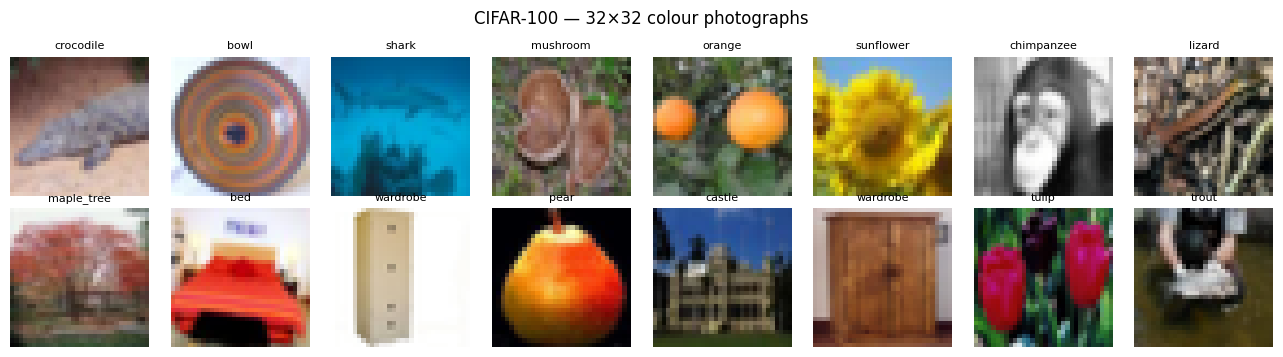

In [12]:
c100_mean = torch.tensor([0.5071, 0.4865, 0.4409]).view(3, 1, 1)   # (3,1,1) so it broadcasts over H,W
c100_std  = torch.tensor([0.2673, 0.2564, 0.2762]).view(3, 1, 1)

images, labels = next(iter(c100_train_loader))

fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for ax, img, lab in zip(axes.flat, images, labels):
    shown = (img * c100_std + c100_mean).clamp(0, 1)     # un-normalise for display
    ax.imshow(shown.permute(1, 2, 0))                    # (C,H,W) -> (H,W,C) for matplotlib
    ax.set_title(CLASSES[lab], fontsize=8); ax.axis("off")
plt.suptitle("CIFAR-100 — 32×32 colour photographs"); plt.tight_layout(); plt.show()

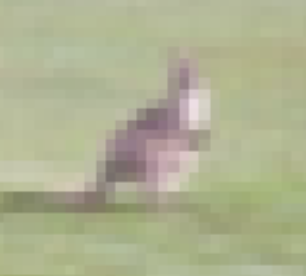

OpenaAI - Chat Completions and Response API

In [ ]:
c100_mlp = MLP(in_features=3*32*32, n_classes=100).to(device)

print(c100_mlp)
mlp_params = sum(p.numel() for p in c100_mlp.parameters())
print(f"\nMNIST MLP parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"CIFAR-100 MLP parameters : {mlp_params:,}   <- 4x bigger, because the input is 4x bigger")

x0, y0 = next(iter(c100_train_loader))
with torch.no_grad():
    logits0 = c100_mlp(x0.to(device))
print(f"\nshape check: {tuple(x0.shape)} -> {tuple(logits0.shape)} ✓")
print(f"untrained loss: {criterion(logits0, y0.to(device)).item():.3f}  (expected ≈ ln 100 = 4.605) ✓")

MLP(
  (fc1): Linear(in_features=3072, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=100, bias=True)
)

MNIST MLP parameters     : 109,386
CIFAR-100 MLP parameters : 408,100   <- 4x bigger, because the input is 4x bigger

shape check: (128, 3, 32, 32) -> (128, 100) ✓
untrained loss: 4.596  (expected ≈ ln 100 = 4.605) ✓


In [ ]:
c100_mlp_criterion = nn.CrossEntropyLoss()
c100_mlp_optimizer = optim.Adam(c100_mlp.parameters(), lr=1e-3)
C100_EPOCHS = 20

c100_mlp_train_loss_hist, c100_mlp_train_acc_hist = [], []
c100_mlp_test_loss_hist,  c100_mlp_test_acc_hist  = [], []

for epoch in range(1, C100_EPOCHS + 1):

    c100_mlp.train()
    run_loss, run_acc = 0.0, 0.0
    for x, y in tqdm(c100_train_loader, desc=f"epoch {epoch}/{C100_EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)

        logits = c100_mlp(x)
        loss   = c100_mlp_criterion(logits, y)

        c100_mlp_optimizer.zero_grad()
        loss.backward()
        c100_mlp_optimizer.step()

        run_loss += loss.item(); run_acc += batch_acc(logits, y)

    train_loss = run_loss / len(c100_train_loader)
    train_acc  = run_acc  / len(c100_train_loader)

    c100_mlp.eval()
    v_loss, v_acc = 0.0, 0.0
    with torch.no_grad():
        for x, y in c100_test_loader:
            x, y = x.to(device), y.to(device)
            logits = c100_mlp(x)
            v_loss += c100_mlp_criterion(logits, y).item(); v_acc += batch_acc(logits, y)

    test_loss = v_loss / len(c100_test_loader)
    test_acc  = v_acc  / len(c100_test_loader)

    c100_mlp_train_loss_hist.append(train_loss); c100_mlp_train_acc_hist.append(train_acc)
    c100_mlp_test_loss_hist.append(test_loss);   c100_mlp_test_acc_hist.append(test_acc)

    print(f"epoch {epoch:>2}/{C100_EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| test loss {test_loss:.4f} acc {test_acc:.4f}")

print(f"\nfinal CIFAR-100 MLP test accuracy: {c100_mlp_test_acc_hist[-1]:.2%}"
      f"   (MNIST MLP got {test_acc_hist[-1]:.2%})")

epoch 1/20:   0%|          | 0/391 [00:00<?, ?it/s]

epoch  1/20 | train loss 3.8728 acc 0.1218 | test loss 3.6387 acc 0.1585


epoch 2/20:   0%|          | 0/391 [00:00<?, ?it/s]

epoch  2/20 | train loss 3.4592 acc 0.1834 | test loss 3.4895 acc 0.1797


epoch 3/20:   0%|          | 0/391 [00:00<?, ?it/s]

...

epoch 18/20 | train loss 2.4364 acc 0.3728 | test loss 3.5033 acc 0.2241


epoch 19/20:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 19/20 | train loss 2.4043 acc 0.3786 | test loss 3.4955 acc 0.2289


epoch 20/20:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 20/20 | train loss 2.3701 acc 0.3861 | test loss 3.5155 acc 0.2252

final CIFAR-100 MLP test accuracy: 22.52%   (MNIST MLP got 97.87%)


In [ ]:
#class CNN(nn.Module):
#    def __init__(self, n_classes=100):
#        super().__init__()

#        self.features = nn.Sequential(
#            # block 1:  (N,3,32,32) -> (N,32,16,16)
#            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
#            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
#            nn.MaxPool2d(2, 2),

#            # block 2:  (N,32,16,16) -> (N,64,8,8)
#            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
#            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
#            nn.MaxPool2d(2, 2),

#            # block 3:  (N,64,8,8) -> (N,128,4,4)
#            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
#            nn.MaxPool2d(2, 2),
#        )

#        self.classifier = nn.Sequential(
#            nn.Flatten(),                                # (N,128,4,4) -> (N,2048)
#            nn.Dropout(0.3),
#            nn.Linear(128 * 4 * 4, n_classes),           # logits, no softmax
#        )

#    def forward(self, x):
#        x = self.features(x)                             # learn WHAT is in the image
#        x = self.classifier(x)                           # decide WHICH class that is
#        return x


#cnn_model = CNN().to(device)
#print(cnn_model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

In [15]:
class CNN(nn.Module):
    def __init__(self, n_classes=100):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),


            # Block 2: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),


            # Block 3: 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),


            # Block 4: 4x4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn_model = CNN(n_classes=100).to(device)

print(cnn_model)
def batch_acc(logits, y):
    # fraction of a batch predicted correctly
    return (logits.argmax(1) == y).float().mean().item()


CNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.2, inpl

In [16]:
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)
CNN_EPOCHS = 20

cnn_train_loss_hist, cnn_train_acc_hist = [], []
cnn_test_loss_hist,  cnn_test_acc_hist  = [], []

for epoch in range(1, CNN_EPOCHS + 1):

    cnn_model.train()                                    # NOW this matters: Dropout + BatchNorm
    run_loss, run_acc = 0.0, 0.0
    for x, y in tqdm(c100_train_loader, desc=f"epoch {epoch}/{CNN_EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)

        logits = cnn_model(x)
        loss   = cnn_criterion(logits, y)

        cnn_optimizer.zero_grad()
        loss.backward()
        cnn_optimizer.step()

        run_loss += loss.item(); run_acc += batch_acc(logits, y)

    train_loss = run_loss / len(c100_train_loader)
    train_acc  = run_acc  / len(c100_train_loader)

    cnn_model.eval()                                     # dropout off, batchnorm uses running stats
    v_loss, v_acc = 0.0, 0.0
    with torch.no_grad():
        for x, y in c100_test_loader:
            x, y = x.to(device), y.to(device)
            logits = cnn_model(x)
            v_loss += cnn_criterion(logits, y).item(); v_acc += batch_acc(logits, y)

    test_loss = v_loss / len(c100_test_loader)
    test_acc  = v_acc  / len(c100_test_loader)

    cnn_train_loss_hist.append(train_loss); cnn_train_acc_hist.append(train_acc)
    cnn_test_loss_hist.append(test_loss);   cnn_test_acc_hist.append(test_acc)

    print(f"epoch {epoch:>2}/{CNN_EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| test loss {test_loss:.4f} acc {test_acc:.4f}")

print(f"\nfinal CIFAR-100 CNN test accuracy: {cnn_test_acc_hist[-1]:.2%}")

epoch 1/20:   0%|          | 0/391 [00:00<?, ?it/s]

epoch  1/20 | train loss 3.8456 acc 0.1012 | test loss 3.3265 acc 0.1932


epoch 2/20:   0%|          | 0/391 [00:00<?, ?it/s]

epoch  2/20 | train loss 3.2253 acc 0.2010 | test loss 2.7855 acc 0.2888


epoch 3/20:   0%|          | 0/391 [00:00<?, ?it/s]

...

epoch 18/20 | train loss 0.9466 acc 0.7123 | test loss 1.3979 acc 0.6212


epoch 19/20:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 19/20 | train loss 0.8719 acc 0.7295 | test loss 1.4114 acc 0.6208


epoch 20/20:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 20/20 | train loss 0.8275 acc 0.7440 | test loss 1.4523 acc 0.6190

final CIFAR-100 CNN test accuracy: 61.90%


In [30]:
# ResNet-101 was pretrained on ImageNet: 3-channel, 224x224, ImageNet mean/std.
# So CIFAR-100 has to be fed to it the SAME way -- upscaled and normalized with
# ImageNet's statistics, not CIFAR's. That means a new transform + new loaders.

resnet_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),               # augment at native 32x32...
    transforms.RandomHorizontalFlip(),
    transforms.Resize(224),                             # ...THEN upscale to ResNet's size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # ImageNet stats, not CIFAR's --
                         std=[0.229, 0.224, 0.225]),    # the pretrained weights expect these
])

resnet_test_transform = transforms.Compose([
    transforms.Resize(224),                             # no augmentation at test time
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

resnet_train_ds = datasets.CIFAR100(DATA_ROOT, train=True,  download=False,
                                    transform=resnet_train_transform)
resnet_test_ds  = datasets.CIFAR100(DATA_ROOT, train=False, download=False,
                                    transform=resnet_test_transform)

RESNET_BATCH = 64                                       # a 224x224 image is 49x a 32x32 one

resnet_train_loader = DataLoader(resnet_train_ds, batch_size=RESNET_BATCH, shuffle=True,
                                 num_workers=0, pin_memory=use_pin)
resnet_test_loader  = DataLoader(resnet_test_ds,  batch_size=RESNET_BATCH, shuffle=False,
                                 num_workers=0, pin_memory=use_pin)

images, labels = next(iter(resnet_train_loader))
print("one batch:", tuple(images.shape), " <- (N, 3, 224, 224), what ResNet expects")
print("(the MNIST train_loader from Part 5 gives (N, 1, 28, 28) -- feed that to ResNet and conv1 errors out)")


one batch: (64, 3, 224, 224)  <- (N, 3, 224, 224), what ResNet expects
(the MNIST train_loader from Part 5 gives (N, 1, 28, 28) -- feed that to ResNet and conv1 errors out)


In [31]:
from torchvision import models


class ResNetCIFAR100(nn.Module):
    def __init__(self, n_classes=100):
        super().__init__()

        # Pretrained ResNet-101 (ImageNet weights, cached after the first download)
        self.model = models.resnet101(
            weights=models.ResNet101_Weights.DEFAULT
        )

        # Number of features going into the original 1000-class FC layer
        in_features = self.model.fc.in_features

        # Replace the classifier head: 1000 ImageNet classes -> 100 CIFAR classes
        self.model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        return self.model(x)

    def train(self, mode=True):
        # requires_grad=False freezes the WEIGHTS. But BatchNorm also carries
        # running_mean / running_var -- normalization statistics that are not
        # learned by gradient descent, so requires_grad cannot touch them. They
        # are updated by the forward pass whenever the layer is in train mode,
        # and .train() below would switch all 104 of ResNet-101's BN layers on.
        # Letting them drift off ImageNet's statistics costs ~15% accuracy here.
        super().train(mode)
        self.model.eval()               # frozen backbone: fixed weights AND fixed stats
        self.model.fc.train(mode)       # head still trains (its dropout stays active)
        return self


resnet_model = ResNetCIFAR100(n_classes=100).to(device)   # own name: `model` is still the MNIST MLP

total     = sum(p.numel() for p in resnet_model.parameters())
head_only = sum(p.numel() for p in resnet_model.model.fc.parameters())
print(f"total parameters : {total:,}")
print(f"new head         : {head_only:,}   <- the only part we train")


total parameters : 43,600,548
new head         : 1,100,388   <- the only part we train


In [32]:
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(loader)
    train_acc = 100 * correct / total

    return train_loss, train_acc


def evaluate(model, loader, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss = running_loss / len(loader)
    test_acc = 100 * correct / total

    return test_loss, test_acc

In [33]:
# Freeze the pretrained backbone -- train ONLY the new head.
# That is the whole point of transfer learning: ResNet's ImageNet features
# already know edges/textures/shapes, so we only learn the 100-way mapping on top.
for param in resnet_model.model.parameters():
    param.requires_grad = False

for param in resnet_model.model.fc.parameters():
    param.requires_grad = True

# the optimizer must only get the parameters we actually train
optimizer = torch.optim.AdamW(
    resnet_model.model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

best_acc = 0

for epoch in range(3):                       # ~3 min/epoch on an M-series GPU

    train_loss, train_acc = train_one_epoch(
        resnet_model,
        resnet_train_loader,                 # CIFAR at 224x224, NOT the MNIST loader
        optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        resnet_model,
        resnet_test_loader,
        device
    )

    print(
        f"Epoch [{epoch+1}/3] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%"
    )

    if test_acc > best_acc:
        best_acc = test_acc

        torch.save(
            resnet_model.state_dict(),
            "best_resnet101_head.pth"
        )

        print("Best model saved!")


Epoch [1/3] | Train Loss: 1.3339 | Train Acc: 63.47% | Test Acc: 73.58%
Best model saved!
Epoch [2/3] | Train Loss: 0.9216 | Train Acc: 72.48% | Test Acc: 75.30%
Best model saved!
Epoch [3/3] | Train Loss: 0.8324 | Train Acc: 74.44% | Test Acc: 76.00%
Best model saved!
